# Clusterização de Ativos e Recomendação de Portfólio

Este notebook implementa a etapa final do pipeline de recomendação:

1. **Clusterização** dos ativos do S&P 500 com base em características de risco e retorno;
2. **Mapeamento** dos clusters para perfis de investidor (Conservador, Moderado, Arrojado);
3. **Construção** de portfólios personalizados para cada perfil;
4. **Avaliação** do desempenho dos portfólios no período de teste (2024–2026).

São comparados dois algoritmos de clusterização:

- **HDBSCAN** — baseado em densidade, descobre o número de clusters automaticamente;
- **K-Means (K=3)** — particiona o espaço em exatamente 3 grupos, um por perfil de investidor.

O HDBSCAN é usado para validar empiricamente o número natural de clusters nos dados.
O K-Means é adotado para a construção dos portfólios por permitir mapeamento
direto e determinístico para os três perfis de usuário.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score

%matplotlib inline

## Configuração do Projeto

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

PREDICTIONS_FILE     = "model_predictions_21d.csv"
FEATURES_FILE        = "sp500_features.csv"
RECOMMENDATIONS_FILE = "portfolio_recommendations.csv"

# Modelo com melhor IC no NB03
BEST_MODEL_COL = "pred_linear_return_21d"

# K-Means
N_CLUSTERS = 3

# HDBSCAN
HDB_MIN_CLUSTER_SIZE = 20
HDB_MIN_SAMPLES      = 5

N_ASSETS_PER_PROFILE = 20
RANDOM_STATE         = 42

## Leitura dos Dados

In [3]:
predictions = pd.read_csv(
    PROCESSED_DATA_DIR / PREDICTIONS_FILE,
    parse_dates=["date"]
)

features = pd.read_csv(
    PROCESSED_DATA_DIR / FEATURES_FILE,
    parse_dates=["date"]
)

test_start    = predictions["date"].min()
features_test = features[features["date"] >= test_start].copy()

print(f"Previsões:        {len(predictions):,} linhas | {predictions['ticker'].nunique()} ativos")
print(f"Período de teste: {predictions['date'].min().date()} -> {predictions['date'].max().date()}")

Previsões:        296,514 linhas | 502 ativos
Período de teste: 2024-01-02 -> 2026-05-13


## Agregação por Ativo

Para cada ativo calculamos características médias ao longo do período de teste:

- **Retorno previsto médio** — proxy do potencial de ganho;
- **Volatilidade média** — proxy do risco;
- **Drawdown médio** — proxy da perda máxima esperada.

In [4]:
asset_pred = (
    predictions
    .groupby("ticker")
    .agg(mean_pred_return=(BEST_MODEL_COL, "mean"))
    .reset_index()
)

asset_risk = (
    features_test
    .groupby("ticker")
    .agg(
        mean_vol_21d=("vol_21d",       "mean"),
        mean_drawdown=("drawdown_63d",  "mean"),
        sector=("sector",    "first"),
        company=("company",   "first")
    )
    .reset_index()
)

assets = asset_pred.merge(asset_risk, on="ticker").dropna()

print(f"Ativos disponíveis para clusterização: {len(assets)}")
assets[["mean_pred_return", "mean_vol_21d", "mean_drawdown"]].describe()

Ativos disponíveis para clusterização: 502


,mean_pred_return,mean_vol_21d,mean_drawdown
count,502.000000,502.000000,502.000000
mean,0.006215,0.018613,-0.077290
std,0.008374,0.006671,0.032188
min,-0.005975,0.009557,-0.243295
25%,0.000428,0.013999,-0.096002
50%,0.004278,0.016847,-0.071117
75%,0.010485,0.021019,-0.054923
max,0.052458,0.052877,-0.023549


## Padronização das Features de Clusterização

Ambos os algoritmos utilizam distância no espaço de features, portanto a padronização
é obrigatória para evitar que features com maior escala dominem o cálculo.

In [5]:
CLUSTER_FEATURES = ["mean_pred_return", "mean_vol_21d", "mean_drawdown"]

scaler    = StandardScaler()
X_cluster = scaler.fit_transform(assets[CLUSTER_FEATURES])

print(f"Matriz de clusterização: {X_cluster.shape}")

Matriz de clusterização: (502, 3)


---
## Parte 1 — HDBSCAN

O HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
identifica clusters como regiões de alta densidade, sem necessidade de especificar K.

Pontos em regiões de baixa densidade são classificados como **ruído** (label `-1`).

Parâmetros principais:
- `min_cluster_size`: número mínimo de ativos para formar um cluster;
- `min_samples`: controla o quão conservador é o algoritmo — valores maiores geram mais ruído.

In [6]:
hdbscan = HDBSCAN(
    min_cluster_size=HDB_MIN_CLUSTER_SIZE,
    min_samples=HDB_MIN_SAMPLES
)

hdb_labels = hdbscan.fit_predict(X_cluster)
assets["hdb_cluster"] = hdb_labels

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise        = (hdb_labels == -1).sum()

print(f"Clusters encontrados: {n_clusters_hdb}")
print(f"Ativos classificados como ruído: {n_noise} ({n_noise / len(hdb_labels) * 100:.1f}%)")
print()
print("Distribuição por cluster:")
for label in sorted(set(hdb_labels)):
    count = (hdb_labels == label).sum()
    nome  = "Ruído" if label == -1 else f"Cluster {label}"
    print(f"  {nome}: {count} ativos")

Clusters encontrados: 3
Ativos classificados como ruído: 181 (36.1%)

Distribuição por cluster:
  Ruído: 181 ativos
  Cluster 0: 21 ativos
  Cluster 1: 25 ativos
  Cluster 2: 275 ativos


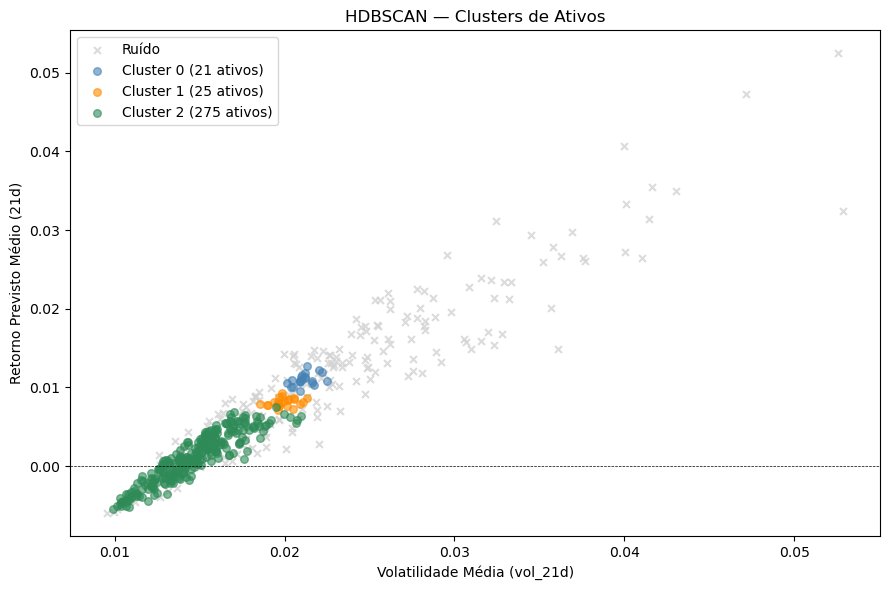

In [7]:
cluster_ids = sorted([l for l in set(hdb_labels) if l != -1])
colors_hdb  = ["steelblue", "darkorange", "seagreen", "purple", "crimson"]

fig, ax = plt.subplots(figsize=(9, 6))

noise = assets[assets["hdb_cluster"] == -1]
ax.scatter(
    noise["mean_vol_21d"], noise["mean_pred_return"],
    color="lightgray", marker="x", s=25, label="Ruído", alpha=0.8
)

for i, cid in enumerate(cluster_ids):
    subset = assets[assets["hdb_cluster"] == cid]
    ax.scatter(
        subset["mean_vol_21d"], subset["mean_pred_return"],
        label=f"Cluster {cid} ({len(subset)} ativos)",
        alpha=0.6, s=30, color=colors_hdb[i % len(colors_hdb)]
    )

ax.set_xlabel("Volatilidade Média (vol_21d)")
ax.set_ylabel("Retorno Previsto Médio (21d)")
ax.set_title("HDBSCAN — Clusters de Ativos")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
hdb_stats = (
    assets[assets["hdb_cluster"] != -1]
    .groupby("hdb_cluster")
    .agg(
        n_ativos=("ticker",           "count"),
        retorno_previsto=("mean_pred_return",  "mean"),
        volatilidade=("mean_vol_21d",       "mean"),
        drawdown=("mean_drawdown",      "mean")
    )
    .round(4)
    .sort_values("volatilidade")
    .reset_index()
)

hdb_stats

,hdb_cluster,n_ativos,retorno_previsto,volatilidade,drawdown
0,2,275,0.0011,0.0146,-0.0590
1,1,25,0.0081,0.0199,-0.0841
2,0,21,0.0110,0.0212,-0.1041


---
## Parte 2 — K-Means

Avaliamos K de 2 a 8 pelo método do cotovelo e pelo Silhouette Score para embasar
a escolha de K=3.

c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to hav

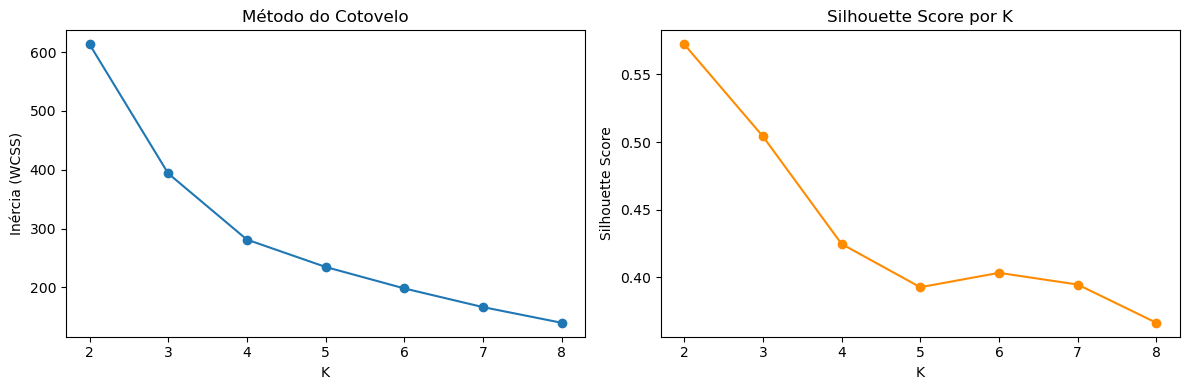

In [9]:
K_range    = range(2, 9)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].set_title("Método do Cotovelo")

axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por K")

plt.tight_layout()
plt.show()

In [10]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
assets["cluster"] = kmeans.fit_predict(X_cluster)

print("Ativos por cluster (K-Means):")
print(assets["cluster"].value_counts().sort_index().to_string())

Ativos por cluster (K-Means):
cluster
0     40
1    310
2    152


c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


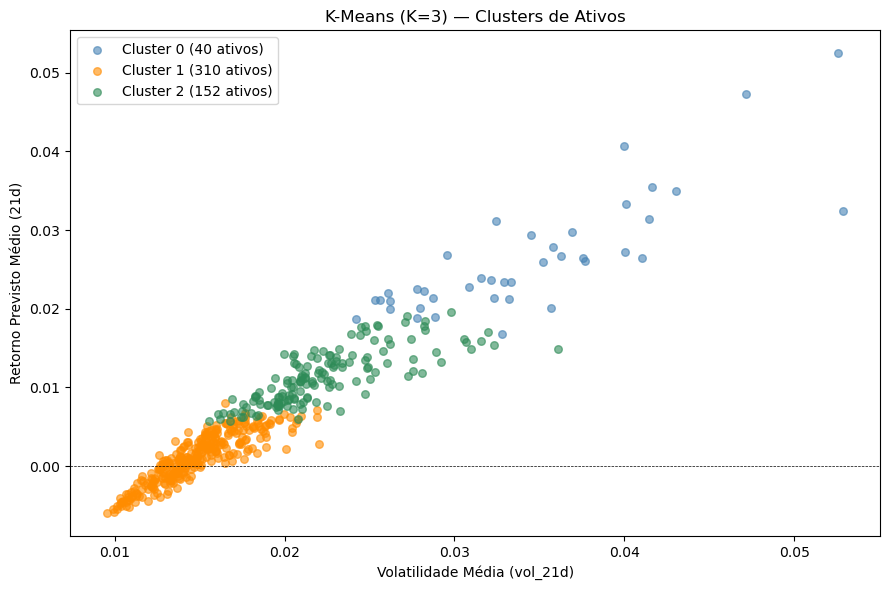

In [11]:
colors_km = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, cid in enumerate(sorted(assets["cluster"].unique())):
    subset = assets[assets["cluster"] == cid]
    ax.scatter(
        subset["mean_vol_21d"], subset["mean_pred_return"],
        label=f"Cluster {cid} ({len(subset)} ativos)",
        alpha=0.6, s=30, color=colors_km[i]
    )

ax.set_xlabel("Volatilidade Média (vol_21d)")
ax.set_ylabel("Retorno Previsto Médio (21d)")
ax.set_title("K-Means (K=3) — Clusters de Ativos")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
km_stats = (
    assets.groupby("cluster")
    .agg(
        n_ativos=("ticker",           "count"),
        retorno_previsto=("mean_pred_return",  "mean"),
        volatilidade=("mean_vol_21d",       "mean"),
        drawdown=("mean_drawdown",      "mean")
    )
    .round(4)
    .sort_values("volatilidade")
    .reset_index()
)

km_stats

,cluster,n_ativos,retorno_previsto,volatilidade,drawdown
0,1,310,0.0011,0.0148,-0.0581
1,2,152,0.0113,0.0222,-0.0997
2,0,40,0.0264,0.0343,-0.1412


---
## Comparação entre HDBSCAN e K-Means

O HDBSCAN revela quantos clusters existem naturalmente nos dados.
Essa informação valida (ou questiona) a escolha de K=3 no K-Means.

- Se HDBSCAN encontrou ~3 clusters → K=3 é empiricamente justificado;
- Se encontrou outro número → K-Means com K=3 é uma simplificação consciente
  motivada pela necessidade de mapeamento direto para os 3 perfis de usuário.

Ativos classificados como ruído pelo HDBSCAN são excluídos da recomendação
pois representam ativos com perfil de risco atípico e difícil de categorizar.

In [13]:
print("=== Resumo Comparativo ===")
print(f"\nHDBSCAN:")
print(f"  Clusters encontrados: {n_clusters_hdb}")
print(f"  Ativos como ruído:    {n_noise} ({n_noise / len(hdb_labels) * 100:.1f}%)")
print(f"  Ativos clusterizados: {len(hdb_labels) - n_noise}")
print(f"\nK-Means (K=3):")
print(f"  Clusters: 3 (fixo)")
print(f"  Ativos clusterizados: {len(assets)} (todos)")
print(f"  Silhouette Score: {sil_scores[N_CLUSTERS - 2]:.4f}")

=== Resumo Comparativo ===

HDBSCAN:
  Clusters encontrados: 3
  Ativos como ruído:    181 (36.1%)
  Ativos clusterizados: 321

K-Means (K=3):
  Clusters: 3 (fixo)
  Ativos clusterizados: 502 (todos)
  Silhouette Score: 0.5042


---
## Mapeamento Clusters → Perfis de Investidor

Os clusters do K-Means são ordenados por volatilidade e mapeados para os perfis:

- **Conservador** → cluster de menor volatilidade;
- **Moderado** → cluster intermediário;
- **Arrojado** → cluster de maior volatilidade.

In [14]:
clusters_by_vol = km_stats.sort_values("volatilidade")["cluster"].tolist()

PROFILE_MAP = {
    clusters_by_vol[0]: "Conservador",
    clusters_by_vol[1]: "Moderado",
    clusters_by_vol[2]: "Arrojado"
}

assets["perfil"] = assets["cluster"].map(PROFILE_MAP)

print("Mapeamento cluster -> perfil:")
for cid, perfil in PROFILE_MAP.items():
    row = km_stats[km_stats["cluster"] == cid].iloc[0]
    print(f"  Cluster {cid} -> {perfil:12s} | vol={row['volatilidade']:.4f} | retorno={row['retorno_previsto']:.4f}")

Mapeamento cluster -> perfil:
  Cluster 1 -> Conservador  | vol=0.0148 | retorno=0.0011
  Cluster 2 -> Moderado     | vol=0.0222 | retorno=0.0113
  Cluster 0 -> Arrojado     | vol=0.0343 | retorno=0.0264


## Distribuição Setorial por Perfil

In [15]:
for perfil in ["Conservador", "Moderado", "Arrojado"]:
    sector_counts = (
        assets[assets["perfil"] == perfil]
        .groupby("sector")["ticker"]
        .count()
        .sort_values(ascending=False)
    )
    print(f"{perfil}:")
    print(sector_counts.to_string())
    print()

Conservador:
sector
Financials                60
Industrials               58
Health Care               28
Real Estate               28
Utilities                 27
Consumer Staples          27
Consumer Discretionary    21
Information Technology    18
Communication Services    17
Materials                 15
Energy                    11

Moderado:
sector
Information Technology    39
Health Care               26
Consumer Discretionary    22
Industrials               18
Financials                13
Energy                    10
Materials                 10
Consumer Staples           8
Real Estate                3
Utilities                  2
Communication Services     1

Arrojado:
sector
Information Technology    15
Communication Services     5
Consumer Discretionary     5
Health Care                5
Financials                 3
Industrials                3
Utilities                  2
Consumer Staples           1
Materials                  1



---
## Construção e Avaliação dos Portfólios

A cada mês, para cada perfil:

1. Identificamos os ativos do cluster correspondente;
2. Selecionamos os `N` com maior retorno previsto **naquela data** (rebalanceamento dinâmico);
3. Calculamos o retorno realizado médio com pesos iguais.

O **benchmark** é o portfólio equally-weighted de todos os ativos disponíveis.

In [16]:
profile_to_cluster = {v: k for k, v in PROFILE_MAP.items()}
PROFILES = ["Conservador", "Moderado", "Arrojado"]

predictions["year_month"] = predictions["date"].dt.to_period("M")
eval_dates = (
    predictions.groupby("year_month")["date"]
    .min()
    .tolist()
)

portfolio_returns = {p: [] for p in PROFILES}
benchmark_returns = []
eval_date_list    = []

for date in eval_dates:
    date_preds = predictions[predictions["date"] == date]
    if date_preds.empty:
        continue

    benchmark_returns.append(date_preds["actual_return_21d"].mean())
    eval_date_list.append(date)

    for perfil in PROFILES:
        cluster_id      = profile_to_cluster[perfil]
        cluster_tickers = assets[assets["cluster"] == cluster_id]["ticker"].tolist()

        pool  = date_preds[date_preds["ticker"].isin(cluster_tickers)]
        top_n = pool.nlargest(N_ASSETS_PER_PROFILE, BEST_MODEL_COL)

        ret = top_n["actual_return_21d"].mean() if len(top_n) > 0 else 0
        portfolio_returns[perfil].append(ret)

perf_df = pd.DataFrame(portfolio_returns, index=eval_date_list)
perf_df["Benchmark"] = benchmark_returns

print(f"Períodos de avaliação: {len(perf_df)}")
print(f"\nRetorno médio por período (21d):")
print((perf_df.mean() * 100).round(2).to_string())

Períodos de avaliação: 29

Retorno médio por período (21d):
Conservador    2.49
Moderado       2.36
Arrojado       5.45
Benchmark      1.64


## Retorno Acumulado

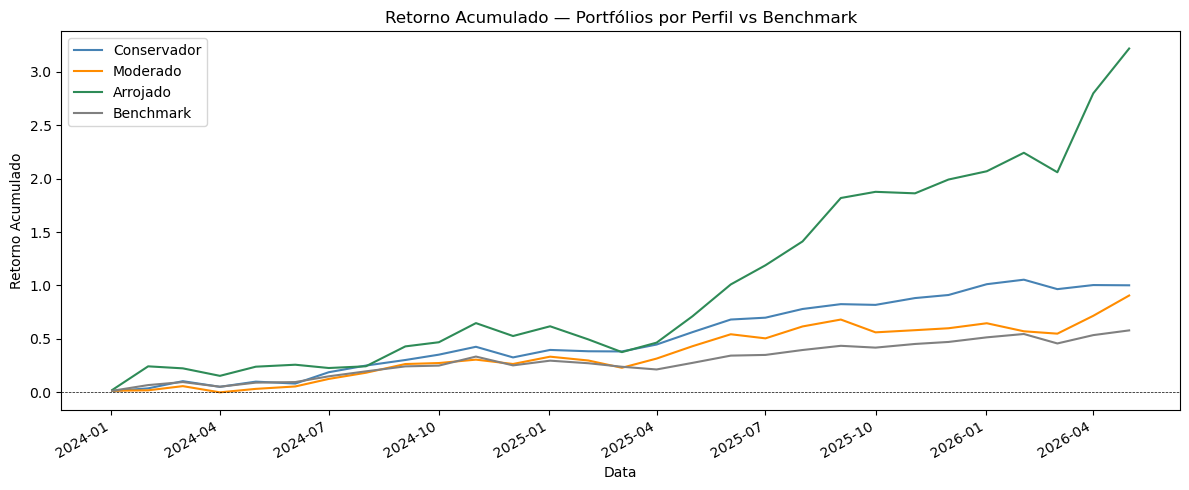

In [17]:
cumulative = (1 + perf_df).cumprod() - 1

cumulative.plot(
    figsize=(12, 5),
    title="Retorno Acumulado — Portfólios por Perfil vs Benchmark",
    color=["steelblue", "darkorange", "seagreen", "gray"]
)
plt.ylabel("Retorno Acumulado")
plt.xlabel("Data")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

## Métricas de Desempenho

In [18]:
n_periods_per_year = 252 / 21

summary = pd.DataFrame({
    "Retorno Total (%)": (cumulative.iloc[-1] * 100).round(2),
    "Retorno Anualizado (%)": (perf_df.mean() * n_periods_per_year * 100).round(2),
    "Volatilidade Anualizada (%)": (perf_df.std() * np.sqrt(n_periods_per_year) * 100).round(2),
    "Sharpe Ratio": (
        perf_df.mean() / perf_df.std() * np.sqrt(n_periods_per_year)
    ).round(3)
})

summary

,Retorno Total (%),Retorno Anualizado (%),Volatilidade Anualizada (%),Sharpe Ratio
Conservador,100.11,29.92,13.48,2.220
Moderado,90.54,28.38,17.20,1.650
Arrojado,321.85,65.34,30.74,2.125
Benchmark,57.88,19.71,11.72,1.681


## Salvamento das Recomendações

In [19]:
recommendations = assets[[
    "ticker", "company", "sector", "cluster", "perfil",
    "mean_pred_return", "mean_vol_21d", "mean_drawdown"
]].copy()

recommendations.to_csv(
    PROCESSED_DATA_DIR / RECOMMENDATIONS_FILE,
    index=False
)

print("Arquivo salvo com sucesso.")
print()
print(recommendations.groupby("perfil")[["ticker"]].count().rename(columns={"ticker": "n_ativos"}).to_string())

Arquivo salvo com sucesso.

             n_ativos
perfil               
Arrojado           40
Conservador       310
Moderado          152
